In [2]:
import pandas as pd

df = pd.read_csv("world_happiness_dataset.csv")

df.head(6)

,Unnamed: 0,country,social_support,freedom,corruption,generosity,gdp_per_cap,life_exp,happiness_score
0,1,Finland,2.0,5.0,4.0,47.0,42400,81.8,155
1,2,Denmark,4.0,6.0,3.0,22.0,48300,81.0,154
2,3,Norway,3.0,3.0,8.0,11.0,66300,82.6,153
3,4,Iceland,1.0,7.0,45.0,3.0,47900,83.0,152
4,5,Netherlands,15.0,19.0,12.0,7.0,50500,81.8,151
5,6,Switzerland,13.0,11.0,7.0,16.0,59000,84.3,150


In [3]:
# Task 1: Calculate the mean, median, and standard deviation of the happiness_score across all countries

happiness = df["happiness_score"]

mean_happiness = happiness.mean()     
median_happiness = happiness.median()  
std_happiness = happiness.std()        

print("TASK 1 - Happiness Score Statistics")
print(f"Mean: {mean_happiness}")
print(f"Median: {median_happiness}")
print(f"Standard deviation: {std_happiness}")

TASK 1 - Happiness Score Statistics
Mean: 77.64335664335664
Median: 79.0
Standard deviation: 46.37741764616525


Top 5 countries by GDP per capita:
       country  gdp_per_cap  happiness_score
27       Qatar       113000              127
13  Luxembourg        94300              142
32   Singapore        90100              122
15     Ireland        72400              140
2       Norway        66300              153


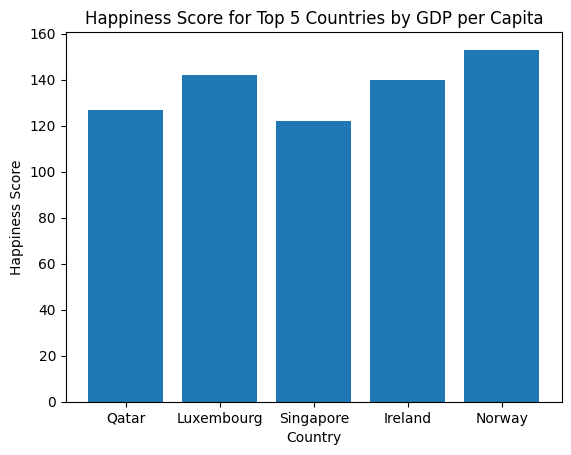

In [4]:
# TASK 2: Identify the top five countries with the highest gdp_per_cap and visualize their happiness_score using a bar chart

import matplotlib.pyplot as plt

top5_gdp = df.sort_values("gdp_per_cap", ascending=False).head(5)

print("Top 5 countries by GDP per capita:")
print(top5_gdp[["country", "gdp_per_cap", "happiness_score"]])

plt.bar(top5_gdp["country"], top5_gdp["happiness_score"])

plt.title("Happiness Score for Top 5 Countries by GDP per Capita")
plt.xlabel("Country")
plt.ylabel("Happiness Score")

plt.show()

TASK 3 - Correlation matrix


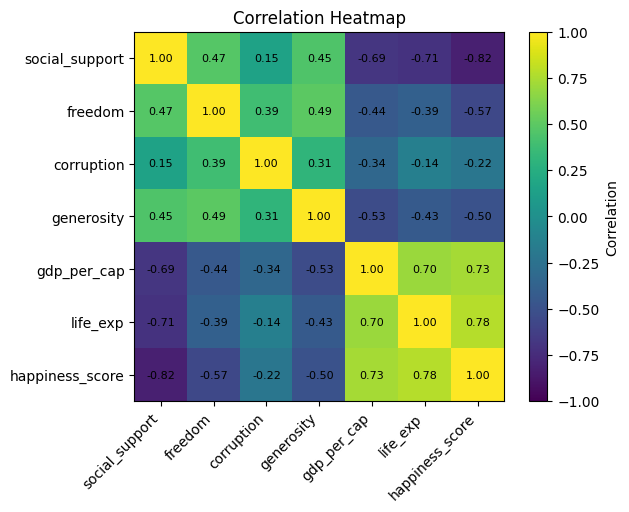

In [6]:
# TASK 3: Compute the correlation matrix for all numerical variables in the dataset

import numpy as np

numeric_df = df.select_dtypes(include="number").copy()

if "Unnamed: 0" in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=["Unnamed: 0"])

corr_matrix = numeric_df.corr()

print("TASK 3 - Correlation matrix")

plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

labels = corr_matrix.columns
n = len(labels)

plt.xticks(np.arange(n), labels, rotation=45, ha="right")
plt.yticks(np.arange(n), labels)

for i in range(n):
    for j in range(n):
        val = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.show()

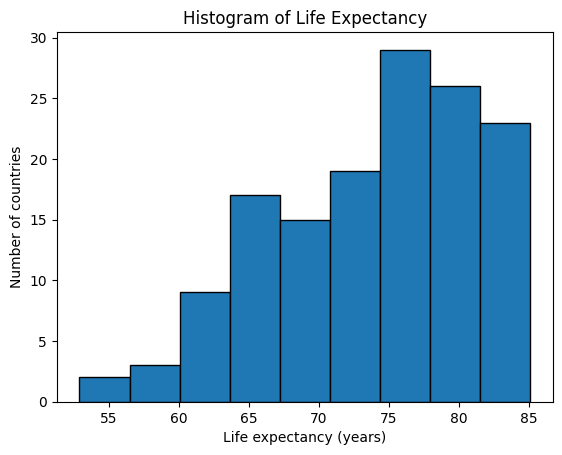

Interpretation: the distribution is left-skewed


In [7]:
# TASK 4: Plot a histogram of life_exp and analyze its distribution

life = df["life_exp"]

plt.figure()
plt.hist(life, bins=9, edgecolor="black")

plt.title("Histogram of Life Expectancy")
plt.xlabel("Life expectancy (years)")
plt.ylabel("Number of countries")

plt.show()

print("Interpretation: the distribution is left-skewed")


In [8]:
# TASK 5: What is the probability that a randomly selected country has a social_support score greater than 50?

social = df["social_support"]

total_countries = len(social)
count_over_50 = (social > 50).sum()

probability = count_over_50 / total_countries
print("TASK 5:")
print(f"Countries with social_support > 50: {count_over_50} out of {total_countries}")
print(f"Probability that social_support > 50: {probability}")

TASK 5:
Countries with social_support > 50: 95 out of 143
Probability that social_support > 50: 0.6643356643356644


In [9]:
# TASK 6: Assuming that the life_exp values are normally distributed, what is the probability that a randomly selected country has a life_exp greater than 80 years?

from scipy.stats import norm

life = df["life_exp"]

mean_life = life.mean()
std_life = life.std()

prob_over_80 = 1 - norm.cdf(80, loc=mean_life, scale=std_life)

print("TASK 6 - Life expectancy > 80 years (assuming normal distribution)")
print(f"Probability: {prob_over_80}")


TASK 6 - Life expectancy > 80 years (assuming normal distribution)
Probability: 0.1908703229127775


TASK 7 - Linear regression: happiness_score ~ gdp_per_cap
Slope (a): 0.001641
Intercept (b): 44.6143
Equation: happiness_score = 0.001641 * gdp_per_cap + 44.6143


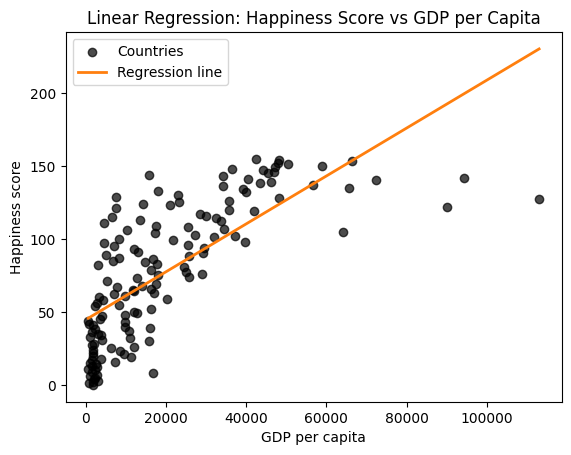

In [10]:
# TASK 7: Perform a linear regression analysis to predict happiness_score based on gdp_per_cap

X = df["gdp_per_cap"].values
y = df["happiness_score"].values

# Fit regression line: y = a*x + b
slope, intercept = np.polyfit(X, y, 1)

print("TASK 7 - Linear regression: happiness_score ~ gdp_per_cap")
print(f"Slope (a): {slope:.6f}")
print(f"Intercept (b): {intercept:.4f}")
print(f"Equation: happiness_score = {slope:.6f} * gdp_per_cap + {intercept:.4f}")

plt.figure()
plt.scatter(X, y, alpha=0.7, label="Countries", color="black")

x_line = np.linspace(X.min(), X.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, linewidth=2, label="Regression line", color="tab:orange")

plt.title("Linear Regression: Happiness Score vs GDP per Capita")
plt.xlabel("GDP per capita")
plt.ylabel("Happiness score")
plt.legend()

plt.show()


TASK 8 - Multiple regression:
happiness_score ~ gdp_per_cap + life_exp + freedom + social_support

Intercept (b0): -21.2326
Coefficient for gdp_per_cap: 0.000439
Coefficient for life_exp: 1.853770
Coefficient for freedom: -0.184720
Coefficient for social_support: -0.420286

R^2: 0.8023


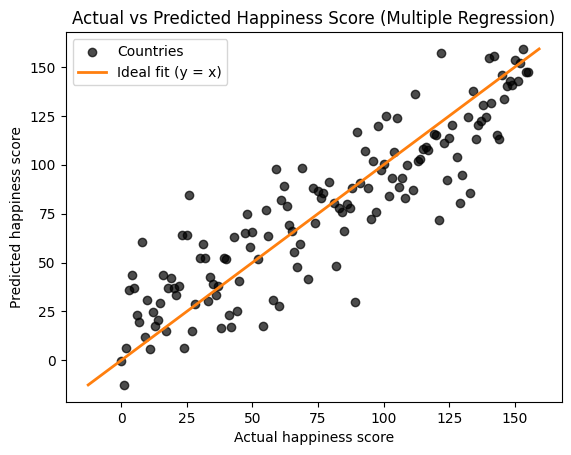

In [11]:
# TASK 8: Predict happiness_score using multiple regression with gdp_per_cap, life_exp, freedom, and social support

from sklearn.linear_model import LinearRegression

features = ["gdp_per_cap", "life_exp", "freedom", "social_support"]

df_clean = df.dropna(subset=features + ["happiness_score"])

X = df_clean[features]
y = df_clean["happiness_score"]

model = LinearRegression()
model.fit(X, y)

print("TASK 8 - Multiple regression:")
print("happiness_score ~ gdp_per_cap + life_exp + freedom + social_support\n")

print("Intercept (b0):", round(model.intercept_, 4))
for name, coef in zip(features, model.coef_):
    print(f"Coefficient for {name}: {coef:.6f}")

r2 = model.score(X, y)
print("\nR^2:", round(r2, 4))

y_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_pred, alpha=0.7, color="black", label="Countries")

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="tab:orange", linewidth=2, label="Ideal fit (y = x)")

plt.title("Actual vs Predicted Happiness Score (Multiple Regression)")
plt.xlabel("Actual happiness score")
plt.ylabel("Predicted happiness score")
plt.legend()
plt.show()

In [12]:
# TASK 9: Is there a significant difference in life_exp between countries above and below median social_support?

from scipy.stats import ttest_ind

df_sub = df[["life_exp", "social_support"]].dropna()

median_support = df_sub["social_support"].median()

life_high = df_sub[df_sub["social_support"] > median_support]["life_exp"]
life_low = df_sub[df_sub["social_support"] <= median_support]["life_exp"]

print("Median social_support:", median_support)
print("Number of countries with high social_support:", len(life_high))
print("Number of countries with low/medium social_support:", len(life_low))
print()

print("Mean life_exp (high social_support):", round(life_high.mean(), 2))
print("Mean life_exp (low/<= median social_support):", round(life_low.mean(), 2))
print()

t_stat, p_value = ttest_ind(life_high, life_low, equal_var=False)

print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: p < 0.05 -> we REJECT the null hypothesis")
    print("There IS a significant difference in life expectancy between the two groups")
else:
    print("\nConclusion: p >= 0.05 -> we DO NOT reject the null hypothesis")
    print("There is NO significant difference in life expectancy between the two groups")


Median social_support: 76.0
Number of countries with high social_support: 71
Number of countries with low/medium social_support: 71

Mean life_exp (high social_support): 69.52
Mean life_exp (low/<= median social_support): 77.98

t-statistic: -8.8342
p-value: 9.373678715757926e-15

Conclusion: p < 0.05 -> we REJECT the null hypothesis
There IS a significant difference in life expectancy between the two groups


In [14]:
# TASK 10: Test whether the average happiness_score differs significantly between countries with life_exp above and below 80
df_sub = df[["happiness_score", "life_exp"]].dropna()

high_life = df_sub[df_sub["life_exp"] > 80]["happiness_score"]
low_life = df_sub[df_sub["life_exp"] <= 80]["happiness_score"]

print("Number of countries with life_exp > 80:", len(high_life))
print("Number of countries with life_exp <= 80:", len(low_life))
print()

print("Mean happiness_score (life_exp > 80): ", round(high_life.mean(), 2))
print("Mean happiness_score (life_exp <= 80):", round(low_life.mean(), 2))
print()

t_stat, p_value = ttest_ind(high_life, low_life, equal_var=False)

print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: p < 0.05 -> Significant difference in average happiness_score between the two groups")
else:
    print("\nConclusion: p >= 0.05 -> No significant difference in average happiness_score between the two groups")


Number of countries with life_exp > 80: 32
Number of countries with life_exp <= 80: 111

Mean happiness_score (life_exp > 80):  129.56
Mean happiness_score (life_exp <= 80): 62.68

t-statistic: 12.2092
p-value: 4.016303248130827e-21

Conclusion: p < 0.05 -> Significant difference in average happiness_score between the two groups
